<a href="https://colab.research.google.com/github/umair594/Machine-Learning-Projects/blob/main/Clustering_Antarctic_Penguin_Species.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 11: Clustering Antarctic Penguin Species**

**K-Means Clustering + PCA Visualization**

**Introduction**

Machine Learning can be broadly classified into supervised and unsupervised learning. While supervised learning relies on labeled data, unsupervised learning discovers hidden patterns and structures within data without predefined labels. One of the most widely used unsupervised learning techniques is K-Means Clustering, which groups similar observations into clusters based on their feature similarities.

In this project, the Palmer Penguins dataset was analyzed using K-Means clustering to identify natural groupings among Antarctic penguins. The dataset contains various physical characteristics of penguins, including bill length, bill depth, flipper length, and body mass. These features provide valuable information for distinguishing between different penguin species.

The project involved several important data science steps, including data cleaning, handling missing values, feature scaling, determining the optimal number of clusters using the Elbow Method and Silhouette Score, and visualizing the clustering results using Principal Component Analysis (PCA). Finally, the discovered clusters were compared with the actual species labels to evaluate how effectively K-Means identified biologically meaningful groups.

The main objective of this project was to explore whether penguin species can be separated based solely on their physical measurements without providing species information to the clustering algorithm.

# **1. Import Libraries**

In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score, confusion_matrix

# **2. Load Dataset**

In [2]:
# Option A: Load from seaborn
import seaborn as sns
df = sns.load_dataset("penguins")

# Option B: Load from CSV
# df = pd.read_csv("penguins.csv")

print(df.head())
print(df.info())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_

# **3. Basic Data Exploration**

In [3]:
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Shape:")
print(df.shape)

print("\nSpecies Counts:")
print(df["species"].value_counts())


Missing Values:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Dataset Shape:
(344, 7)

Species Counts:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


# **4. Handle Missing Values**

In [4]:
df_clean = df.copy()

numeric_cols = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

categorical_cols = ["island", "sex"]

# Fill numeric missing values with median
for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill categorical missing values with mode
for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("\nMissing Values After Cleaning:")
print(df_clean.isnull().sum())


Missing Values After Cleaning:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


# **5. Feature Selection**

In [5]:
X = df_clean[numeric_cols]

# Optional: include categorical variables
# X = pd.get_dummies(df_clean[numeric_cols + categorical_cols], drop_first=True)

# True species labels are saved only for comparison later
true_labels = df_clean["species"]

# **6. Scale Features**

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# **7. Find Best K Using Elbow Method**

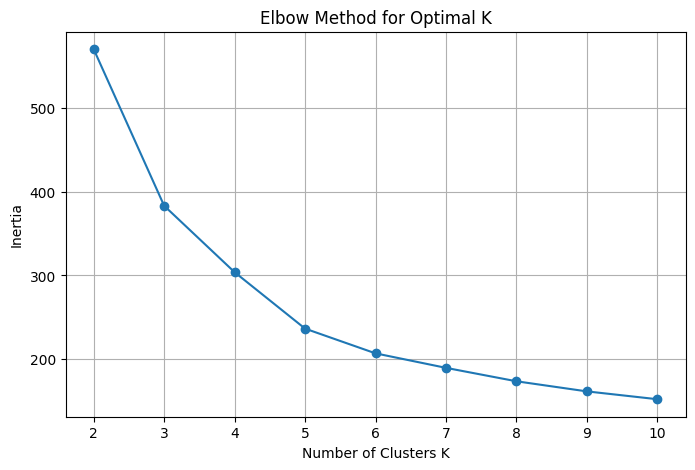

In [7]:
inertia_values = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters K")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

# **8. Find Best K Using Silhouette Score**

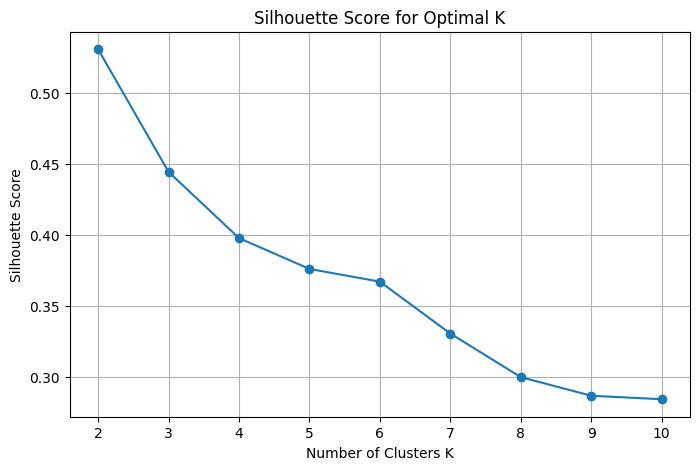


Best K based on Silhouette Score: 2


In [8]:
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.title("Silhouette Score for Optimal K")
plt.xlabel("Number of Clusters K")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

best_k = k_values[np.argmax(silhouette_scores)]
print(f"\nBest K based on Silhouette Score: {best_k}")

# **9. Train Final K-Means Model**

In [9]:
final_k = 4   # You can change this to best_k if preferred

kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df_clean["cluster"] = kmeans_final.fit_predict(X_scaled)

print("\nCluster Counts:")
print(df_clean["cluster"].value_counts())



Cluster Counts:
cluster
1    132
3     89
0     66
2     57
Name: count, dtype: int64


# **10. PCA for 2D Visualization**

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_clean["PC1"] = X_pca[:, 0]
df_clean["PC2"] = X_pca[:, 1]

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)



Explained Variance Ratio:
[0.68837221 0.19313603]


# **11. Plot K-Means Clusters**

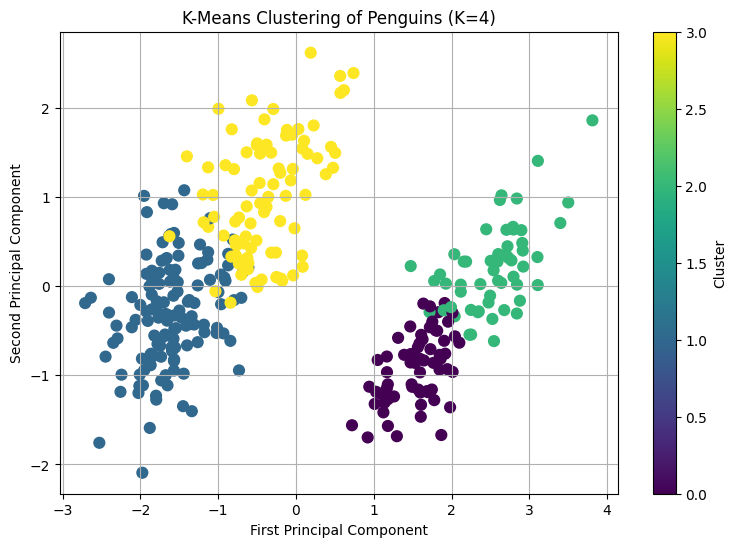

In [11]:
plt.figure(figsize=(9, 6))
plt.scatter(
    df_clean["PC1"],
    df_clean["PC2"],
    c=df_clean["cluster"],
    cmap="viridis",
    s=60
)

plt.title(f"K-Means Clustering of Penguins (K={final_k})")
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

# **12. Compare Clusters with Actual Species**

In [12]:
comparison_table = pd.crosstab(
    df_clean["species"],
    df_clean["cluster"]
)

print("\nSpecies vs Cluster Comparison:")
print(comparison_table)

# Adjusted Rand Index
ari_score = adjusted_rand_score(true_labels, df_clean["cluster"])
print(f"\nAdjusted Rand Index: {ari_score:.4f}")


Species vs Cluster Comparison:
cluster     0    1   2   3
species                   
Adelie      0  127   0  25
Chinstrap   0    5   0  63
Gentoo     66    0  57   1

Adjusted Rand Index: 0.6260


# **13. Cluster Profile Analysis**


Cluster Profiles:
         bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
cluster                                                               
0             45.528788      14.328788         213.106061  4692.803030
1             38.208333      18.110606         188.401515  3584.659091
2             49.792982      15.738596         221.912281  5519.736842
3             47.456180      18.729213         196.898876  3905.337079


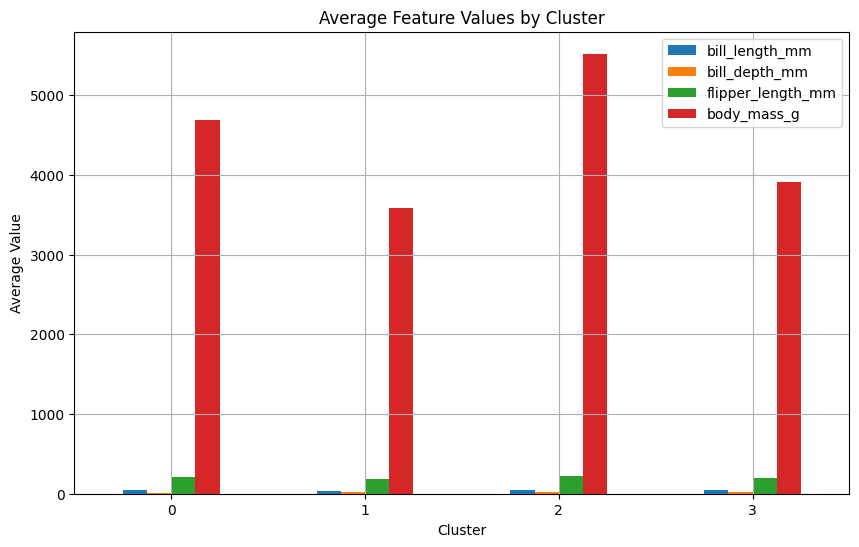

In [13]:
cluster_profile = df_clean.groupby("cluster")[numeric_cols].mean()

print("\nCluster Profiles:")
print(cluster_profile)

cluster_profile.plot(kind="bar", figsize=(10, 6))
plt.title("Average Feature Values by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

# **14. Visualize Actual Species with PCA**

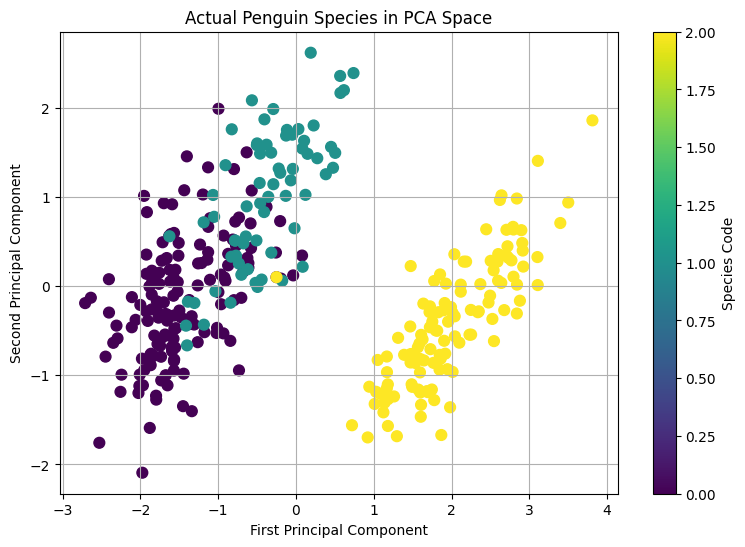

In [14]:
species_codes = true_labels.astype("category").cat.codes

plt.figure(figsize=(9, 6))
plt.scatter(
    df_clean["PC1"],
    df_clean["PC2"],
    c=species_codes,
    cmap="viridis",
    s=60
)

plt.title("Actual Penguin Species in PCA Space")
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.colorbar(label="Species Code")
plt.grid(True)
plt.show()

# **15. Save Final Dataset with Clusters**

In [15]:
df_clean.to_csv("penguin_clusters_output.csv", index=False)

print("\nFinal clustered dataset saved as penguin_clusters_output.csv")


Final clustered dataset saved as penguin_clusters_output.csv


# **16. Predict Cluster for New Penguin**

In [16]:
new_penguin = pd.DataFrame({
    "bill_length_mm": [45.0],
    "bill_depth_mm": [17.5],
    "flipper_length_mm": [200],
    "body_mass_g": [4200]
})

new_penguin_scaled = scaler.transform(new_penguin)
predicted_cluster = kmeans_final.predict(new_penguin_scaled)

print(f"\nPredicted Cluster for New Penguin: {predicted_cluster[0]}")


Predicted Cluster for New Penguin: 3


# **Overall Result:**

 The project successfully demonstrated that K-Means clustering can effectively group Antarctic penguins based on their morphological features, revealing hidden patterns and species-related structures within the dataset.

# **What I Learned From This Project?**

>Learned how to apply K-Means Clustering for unsupervised learning.

>Understood the importance of data cleaning and handling missing values.

>Learned how to scale features using StandardScaler.

>Used the Elbow Method and Silhouette Score to find the optimal number of clusters.

>Applied Principal Component Analysis (PCA) for dimensionality reduction and visualization.

>Gained experience in identifying hidden patterns and groups in data without labels.

>Learned how to evaluate clustering results by comparing them with actual species information.

>Improved skills in data preprocessing, clustering, visualization, and exploratory data analysis (EDA).

Overall, this project helped me understand how unsupervised machine learning can discover meaningful patterns and group similar observations in real-world datasets.